In [91]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm
import seaborn as sns
from scipy import stats
from scipy.stats import linregress
from sklearn.preprocessing import StandardScaler
scale = StandardScaler()
plt.rcParams.update({'font.size': 10, 'figure.figsize': (12, 6)})

In [92]:
df = pd.read_spss("..\\ZA6980_v2-0-0.sav\\ZA6980_v2-0-0.sav")
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44492 entries, 0 to 44491
Columns: 356 entries, studyno to PARTIALS
dtypes: category(352), float64(1), object(3)
memory usage: 18.1+ MB


questions we tested:  

loneliness (?) metric:
 1. How often in the past 4 weeks have you felt that…  
 v31:  you lack companionship?  
 v32: you are isolated from others?   
 v33:  you are left out?  

 2. During the past 4 weeks how often…
v55: have you felt unhappy and depressed? 
v56:  have you felt difficulties were piling up so high that you could not overcome them?  

3. v58: All things considered, how satisfied are you with your life as a whole nowadays? 


Trust metric:
with regrad to people in general:

1. v34: How often do you think that people would try to take advantage of you if they got the 
chance, and how often would they try to be fair?  

2. v35:  Generally speaking, would you say that people can be trusted or that you can’t be too 
careful in dealing with people?

with regard to the judicial system and private corporations:

3. Q12:please indicate how much trust you personally have in  
v36: courts
v37: major private companies 
these answers are already numerical 0 - 10


family connections:

1. v48:think about the parent you have contact with most frequently: How often do you 
have contact with that parent, either face-to-face, by phone, internet or any other 
communication device? 

2. v46:Please indicate about how many people do you have contact with on a typical weekday 
irrespective of whether you know them or not.

3. v47:About how many of *these people do you see face-to-face on a typical weekday?  
*Refers to the previous question.

4. v53: Think now of your contact with all of your family members and close friends. How much of 
it is through text messages, mobile phones, or other communication devices that use the 
internet?

5. v41: In general, do your family members put pressure on you about the way you live or organise 
your personal life? 

6. v42: Do you feel that your family, relatives and/or friends make too many demands on you?  

7. v49: Think about the brother or sister you have contact with most frequently: How often do you 
have contact with that brother or sister, either face-to-face, by phone, internet or any other 
communication device? 

8. v50: Think about your adult child you have contact with most frequently: How often do you 
have contact with this child aged at least 18, either face-to-face, by phone, internet or any other 
communication device?

9. v51:  Now, think about the other family member you have contact with most frequently, aside of 
your spouse or partner, parents, siblings or adult children. How often do you have contact with 
that family member, either face-to-face, by phone, internet or any other communication device?  
 

friend connections:

1. v44:How often do you go out to eat or drink with three or more friends or acquaintances who 
are not family members? 

2. v45:At these occasions, how often do you make new friends or acquaintances?
*referring to v44

3. v52:think about the close friend you have contact with most frequently: How often do you 
have contact with that close friend, either face-to-face, by phone, internet or any other 
communication device?  

4. v17:  In the past 12 months, how often, if at all, have you taken part in activities of groups or 
associations for leisure, sports or culture ?

In [93]:
# Mappings we used to convert the categorical responses to numerical values
#non matching values will be mapped to NaN


v55ResToNum = {
    'Never': -2,
    'Rarely' :-1, 
    'Sometimes': 0,
    'Often': 1,
    'Very often': 2, 
    }

getv55Num = lambda x: v55ResToNum[x] if isinstance(x,str) else -9


v52ResToNum = {
    'I do not have any close friends': -5,
    'Never' : -3,
    'Less often': -2,
    'Several times a year': -1,
    'Once a month': 0,
    'Two to three times a month': 1,
    'Once a week': 2,
    'Several times a week':3,
    'Daily': 4,
    'The close friend I have contact with the most frequently liv': 5
}

getv52Num = lambda x:  v52ResToNum[x] if isinstance(x,str) else -9


v48ResToNum = {
    'My parents are no longer alive': -5,
    'Never' : -3,
    'Less often': -2,
    'Several times a year': -1,
    'Once a month': 0,
    'Two to three times a month': 1,
    'Once a week': 2,
    'Several times a week':3,
    'Daily': 4,
    'The parent I have contact with the most frequently lives wit': 5
}

getv48Num = lambda x:  v48ResToNum[x] if isinstance(x,str) else -9

time_frequency_mapping = {
    'Daily': 3,
    'Several times a week': 2, 
    'Once a week' : 1,
    'Two or three times a month': 1,
    'Once a month' : 0,
    'Several times a year' : -1,
    'Less often' : -2,
    'Never': -3
}

general_frequency_mapping = {
    'Never': -2,    
    'Rarely': -1,
    'Sometimes': 0,
    'Often': 1,
    'Very often': 2
}

getGeneralFrequency = lambda x:  general_frequency_mapping[x] if isinstance(x,str) else -9
getTimeFrequency = lambda x:  time_frequency_mapping[x] if isinstance(x,str) else -9


agreement_mapping = {
    'Strongly agree': 2,
    'Agree': 1,
    'Neither agree nor disagree': 0,
    'Disagree': -1,
    'Strongly disagree': -2
}

ageStringMap = {
    '103 years old': 103,
    '89 (US: 89 years or older)' : 89,
    '15 years old': 15
}

def is_float(s):
    try: 
        float(s)
    except ValueError:
        return False
    else:
        return True

getage = lambda x: float(x) if is_float(x)  else ageStringMap[x]


In [94]:

v49ResToNum = {
    'I do not have any brothers or sisters': -5,
    'Never' : -3,
    'Less often': -2,
    'Several times a year': -1,
    'Once a month': 0,
    'Two to three times a month': 1,
    'Once a week': 2,
    'Several times a week':3,
    'Daily': 4,
    'The brother or sister I have contact with the most frequentl': 5
}

getv49Num = lambda x:  v49ResToNum[x] if isinstance(x,str) else -9

v51ResToNum = {
    'I do not have other family members': -5,
    'Never' : -3,
    'Less often': -2,
    'Several times a year': -1,
    'Once a month': 0,
    'Two to three times a month': 1,
    'Once a week': 2,
    'Several times a week':3,
    'Daily': 4,
    'The other family member I have contact with the most frequen': 5
}

getv51Num = lambda x:  v51ResToNum[x] if isinstance(x,str) else -9

In [95]:
#second part mapping
Q9_mapping = {
    'Never': -2,    
    'Rarely': -1,
    'Sometimes': 0,
    'Often': 1,
    'Very often': 2
}

v17_mapping = {
    'Never': -2,
    'Once in the past year': -1,
    'Several times in the past year': 0,
    'One to three times a month': 1,
    'Once a week or more': 2
}


v58_mapping ={
    "Completely satisfied": 3, 
    "Very satisfied": 2, 
    "Fairly satisfied": 1,
    "Neither satisfied nor dissatisfied": 0, 
    "Fairly dissatisfied": -1,
    "Very dissatisfied": -2,
    "Completely dissatisfied": -3 
}

v34_mapping ={
    "Try to take advantage almost all of the time": 2,
    "Try to take advantage most of the time": 1,
    "Can’t choose ": 0, 
    "Try to be fair most of the time": 1, 
    "Try to be fair almost all of the time": 2
}

v35_mapping ={
    "People can almost always be trusted": 2, 
    "People can usually be trusted": 1, 
     "Can’t choose": 0,
    "You almost always can’t be too careful in dealing with people": -1,
    "You usually can’t be too careful in dealing with people": -2,
}

#talks of pressure from family to conform, hence the less frequent answers are positive
v41_mapping = {
    "No, never": 2 ,
    "Yes, but rarely": 1,
    "Yes, sometimes": 0,
    "Yes, often": -1,
    "Yes, very often": -2,
}

V46_mapping ={
    "0-4 people": -3 ,
    "5-9 people": -2,
    "10-19 people": -1,
    "Can’t choose": 0,
    "20-49 people": 1,
    "50-99 people": 2,
    "100 or more people": 3
}

v47_mapping = {
    "All or almost all of them": 2,
    "Most of them": 1,
    "About half of them": 0,
    "Some of them": -1,
    "None or almost none of them": -2
}

v48_mapping = {
    'Never' : -4,
    'Less often': -3,
    'Several times a year': -2,
    'Once a month': -1,
    'Two to three times a month': 0,
    'Once a week': 1,
    'Several times a week':2,
    'Daily':3,
    'The parent I have contact with the most frequently lives with me': 4
}

v49_mapping = {
"The brother or sister I have contact with the most frequently lives with me" : 4, 
"Daily": 3, 
"Several times a week": 2,
"Once a week": 1,
"Two to three times a month": 0,
"Once a month": -1,
"Several times a year": -2,
"Less often": -3,
"Never": -4
}

v50_mapping = {
    "The child I have contact with the most frequently lives with me": 4,
    "Daily": 3,
    "Several times a week": 2,
    "Once a week": 1,
    "Two to three times a month": 0,
    "Once a month": -1,
    "Several times a year": -2,
    "Less often": -3,
    "Never": -4
}

v51_mapping = {
    "The other family member I have contact with the most frequently lives with me": 4,
    "Daily": 3,
    "Several times a week": 2,
    "Once a week": 1,
    "Two to three times a month": 0,
    "Once a month": -1,
    "Several times a year": -2,
    "Less often": -3,
    "Never": -4
}



#more online communication rather then face to face might increase one's loneliness so it's mapped to a more negative score
v53_mapping= {
    'All or almost all of it': -2,
    'Most of it': -1,
    'About half of it': 0,
    'Some of it': 1,
    'None or almost none of it': 2
}

v44_mapping ={
    "Daily": 4, 
    "Several times a week": 3,
    "Once a week": 2, 
    "Two to three times a month": 1 ,
    "Can’t choose" :0,
    "Once a month": -1 ,
    "Several times a year": -2, 
    "Less often": -3, 
    "Never":-4
}

v45_mapping = {
    "Never": -1, 
    "Rarely": -1,
    "Sometimes": 0, 
    "Often": 1,
    "Very often": 2
}

v52_mapping = {
    "The close friend I have contact with the most frequently lives with me": 4,
    "Daily": 3,
    "Several times a week": 2,
    "Once a week": 1,
    "Two to three times a month": 0,
    "Once a month": -1,
    "Several times a year": -2,
    "Less often": -3,
    "Never": -4
}


In [96]:
#questions mapping:

#lonliness
v31_mapped = df["v31"].map(Q9_mapping).astype(float)
v32_mapped = df["v32"].map(Q9_mapping).astype(float)
v33_mapped = df["v33"].map(Q9_mapping).astype(float)
v55_mapped = df["v55"].map(Q9_mapping).astype(float)
v56_mapped = df["v56"].map(Q9_mapping).astype(float)
v58_mapped = df["v58"].map(v58_mapping).astype(float)

#trust
v34_mapped = df["v34"].map(v34_mapping).astype(float)
v35_mapped = df["v35"].map(v35_mapping).astype(float)
v36_mapped = (pd.to_numeric(df['v36'], errors='coerce') - 5) * (3/5)
v37_mapped = (pd.to_numeric(df['v37'], errors='coerce') - 5) * (3/5)


#family
v46_mapped = df["v46"].map(V46_mapping).astype(float)
v47_mapped = df["v47"].map(v47_mapping).astype(float)
v53_mapped = df["v53"].map(v53_mapping).astype(float)
v48_mapped = df["v48"].map(v48_mapping).astype(float)
v41_mapped = df["v41"].map(v41_mapping).astype(float)
v42_mapped = df["v42"].map(v41_mapping).astype(float)
v49_mapped = df["v49"].map(v49_mapping).astype(float)
v50_mapped = df["v50"].map(v50_mapping).astype(float)
v51_mapped = df["v51"].map(v51_mapping).astype(float)

#friends
v44_mapped = df["v44"].map(v44_mapping).astype(float)
v45_mapped = df["v45"].map(v45_mapping).astype(float)
v46_mapped = df["v46"].map(V46_mapping).astype(float)
v47_mapped = df["v47"].map(v47_mapping).astype(float)
v52_mapped = df["v52"].map(v52_mapping).astype(float)
v17_mapped = df["v17"].map(v17_mapping).astype(float)




0.07407270568283747


,v55
v48,
-9,-4.899807
-5,-1.083026
-3,-1.038889
-2,-0.913295
-1,-0.932741
0,-1.020601
1,-1.026411
2,-1.053008
3,-1.076562


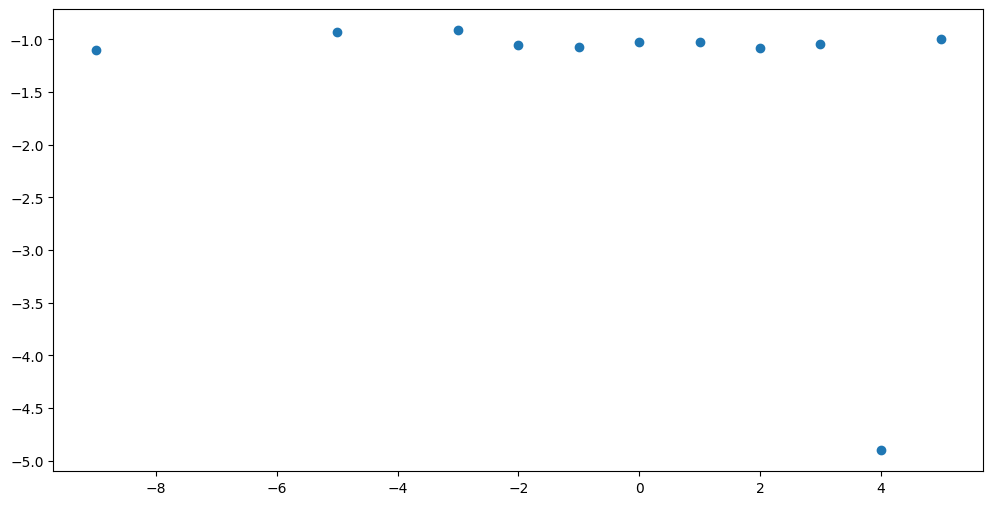

In [97]:
#check by distribution of 48 to 55
v48, v55=df["v48"].map(getv48Num), df["v55"].map(getv55Num)
v55v48 =pd.merge(v48,v55, left_index= True, right_index= True).dropna().groupby("v48").mean()

plt.scatter(v48.unique(),v55v48["v55"])
print(v48.corr(v55))
v55v48


In [98]:
# map values and get mean by country and age

#get Q21 mean
v48 = df["v48"].map(v48ResToNum).astype(float)
v48C = pd.concat([v48, df["c_alphan"]], axis=1).groupby("c_alphan").mean() # by country
v48A = pd.concat([v48, df["AGE"]], axis=1).groupby("AGE").mean() # by age

#get Q25 mean
v52=df["v52"].map(getv52Num)
v52C =pd.merge(v52,df["c_alphan"], left_index= True, right_index= True).groupby("c_alphan").mean() # by country
v52A =pd.merge(v52,df["AGE"], left_index= True, right_index= True).groupby("AGE").mean() # by age

#get Q28 mean
v55=df["v55"].map(getv55Num)
v55C =pd.merge(v55,df["c_alphan"], left_index= True, right_index= True).groupby("c_alphan").mean() # by country
v55A =pd.merge(v55,df["AGE"], left_index= True, right_index= True).groupby("AGE").mean() # by age

#get common index
countries = v52C.index.tolist()
x = np.arange(len(countries)).astype(float)
ages = df["AGE"].map(getage)


C:\Users\shach\AppData\Local\Temp\ipykernel_9824\3655680574.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  v48A = pd.concat([v48, df["AGE"]], axis=1).groupby("AGE").mean() # by age
C:\Users\shach\AppData\Local\Temp\ipykernel_9824\3655680574.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  v52A =pd.merge(v52,df["AGE"], left_index= True, right_index= True).groupby("AGE").mean() # by age
C:\Users\shach\AppData\Local\Temp\ipykernel_9824\3655680574.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain curr

np.float64(0.057171223136410376)

Text(0.5, 1.0, 'friends family corrlation (dots are pairs paired by country)')

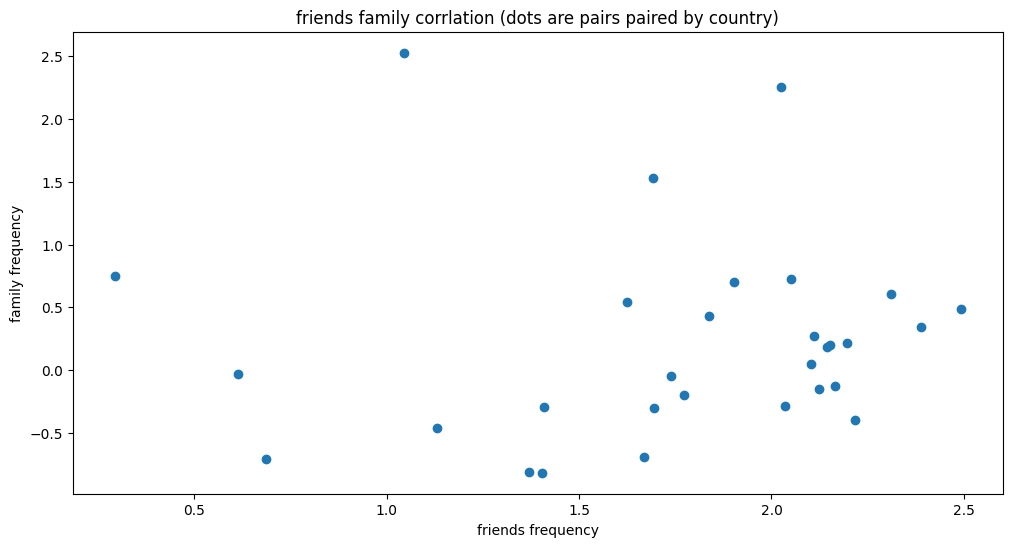

In [99]:
#friends family corrlation by country
display(v52C["v52"].corr(v48C["v48"]))

v52v48c = v52C.merge(v48C, on="c_alphan")

v52v48c["v52"].corr(v52v48c["v48"])

plt.scatter(v52v48c["v52"], v52v48c["v48"])
plt.xlabel("friends frequency")
plt.ylabel("family frequency")
plt.title("friends family corrlation (dots are pairs paired by country)")

corr parents hangout to how depressed: -0.19180580418475254
corr friends hangout to how depressed: 0.2810161077685414


Text(0.5, 1.0, 'Corr between friends/parents hangouts to How depressed')

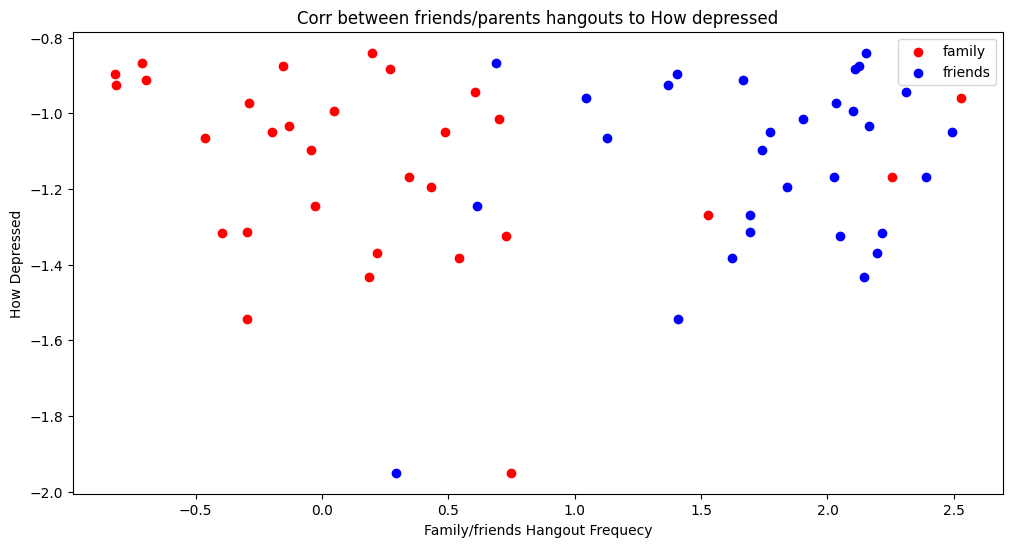

In [100]:
#Corr between friends/parents hangouts to How depressed by country
print("corr parents hangout to how depressed:",v55C["v55"].corr(v48C["v48"]))

v55v48c = v55C.merge(v48C, on="c_alphan")

plt.scatter(v55v48c["v48"], v55v48c["v55"], color="red" )

print("corr friends hangout to how depressed:",v55C["v55"].corr(v52C["v52"]))

v55v52c = v55C.merge(v52C, on="c_alphan")

plt.scatter(v55v52c["v52"], v55v52c["v55"], color="blue")
plt.legend(labels= ["family","friends"])
plt.xlabel("Family/friends Hangout Frequecy")
plt.ylabel("How Depressed")
plt.title("Corr between friends/parents hangouts to How depressed")

Text(0.5, 1.0, 'Q21,Q25,Q28 questions answers by age')

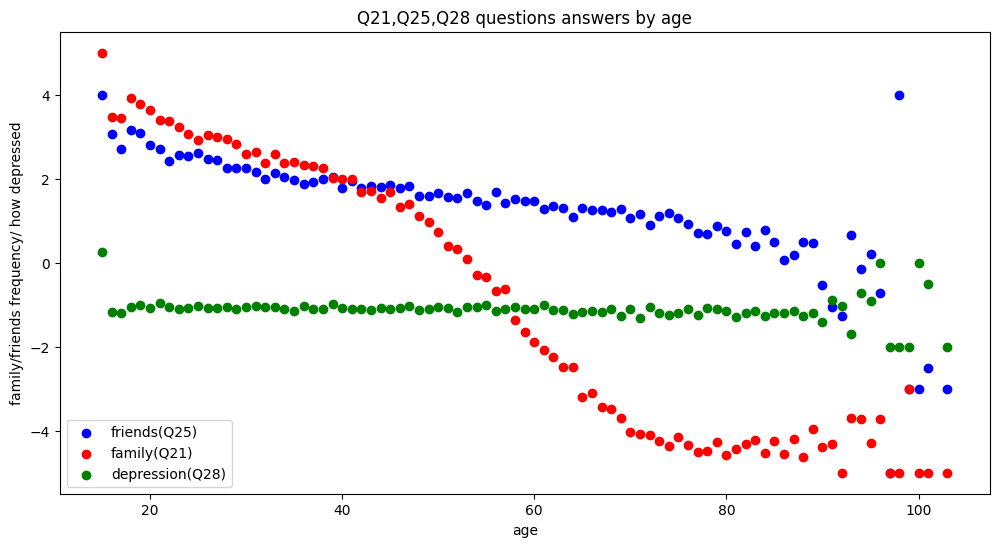

In [101]:
# aQ21,Q25,Q28 questions by age
plt.scatter(v52A.index.map(getage), v52A["v52"], color = 'blue')
plt.scatter(v52A.index.map(getage), v48A["v48"], color = 'red')
plt.scatter(v52A.index.map(getage), v55A["v55"], color = 'green')
plt.legend(labels  =["friends(Q25)", "family(Q21)", "depression(Q28)"])
plt.xlabel("age")
plt.ylabel("family/friends frequency/ how depressed")
plt.title("Q21,Q25,Q28 questions answers by age")

corr Q21 Q25: 0.6986745489347445


Text(0.5, 1.0, 'friends family correlation (dots are pairs paired by age)')

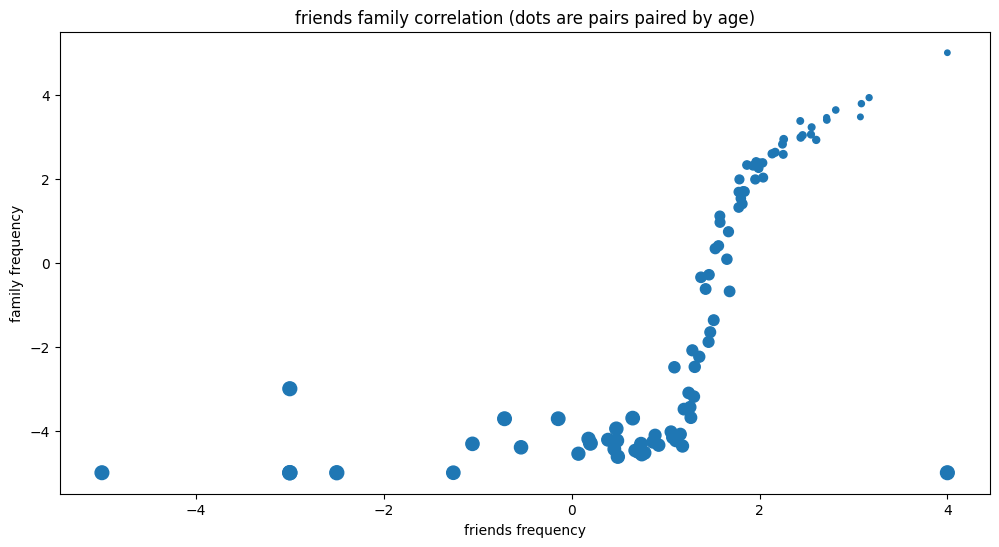

In [102]:
# friends family correlation by age
print("corr Q21 Q25:",v52A["v52"].corr(v48A["v48"]))

v52v48a = v52A.merge(v48A, on="AGE")
fig, ax = plt.subplots()


plt.scatter(v52v48a["v52"], v52v48a["v48"], s= v52v48a.index.map(getage))
plt.xlabel("friends frequency")
plt.ylabel("family frequency")
#for i, txt in enumerate(v52v48a.index.map(getage)):
    #ax.annotate(txt, (v52v48a["v52"][i], v52v48a["v48"][i]))
plt.title("friends family correlation (dots are pairs paired by age)")

In [103]:
# polynomial regression for friends family correlation
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

polyFeat = PolynomialFeatures(degree =2, include_bias =False)
y = v52v48a["v48"]
x = pd.DataFrame(v52v48a["v52"])

lin = LinearRegression()
lin.fit(x, y)

x_poly = polyFeat.fit_transform(x)
polyFeat.fit(x_poly, y)

x_poly = sm.add_constant(x_poly)
model = sm.OLS(y ,x_poly)
result = model.fit()

print(result.summary())



                            OLS Regression Results                            
Dep. Variable:                    v48   R-squared:                       0.616
Model:                            OLS   Adj. R-squared:                  0.607
Method:                 Least Squares   F-statistic:                     68.10
Date:                Fri, 23 Jan 2026   Prob (F-statistic):           2.22e-18
Time:                        23:13:03   Log-Likelihood:                -184.91
No. Observations:                  88   AIC:                             375.8
Df Residuals:                      85   BIC:                             383.3
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -3.8435      0.341    -11.272      0.0

corr parents hangout to how depressed: 0.2355653592855432
corr friends hangout to how depressed: 0.16474489471830223


Text(0.5, 1.0, 'friends family correlation to how depressed you are')

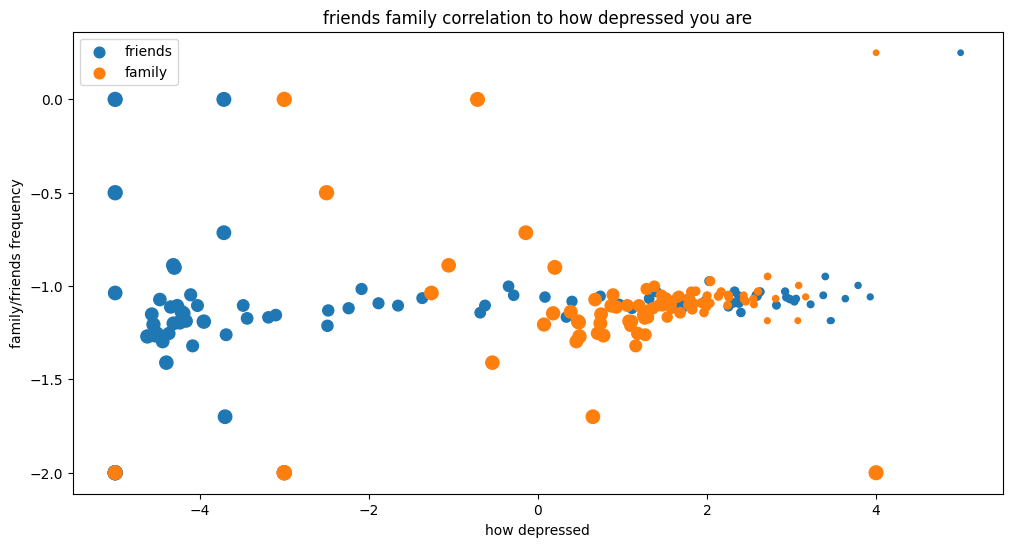

In [104]:
# Q21, Q25 to how depressed
print("corr parents hangout to how depressed:",v55A["v55"].corr(v48A["v48"]))

v55v48a = v55A.merge(v48A, on="AGE")

plt.scatter(v55v48a["v48"], v55v48a["v55"], s= v55v48a.index.map(getage))

print("corr friends hangout to how depressed:",v55A["v55"].corr(v52A["v52"]))

v55v52a = v55A.merge(v52A, on="AGE")

plt.scatter(v55v52a["v52"], v55v52a["v55"], s= v55v52a.index.map(getage))
plt.legend(labels  =["friends", "family"])
plt.xlabel("how depressed")
plt.ylabel("family/friends frequency")
plt.title("friends family correlation to how depressed you are")

In [105]:
v43 = df["v43"].map(getGeneralFrequency)
v43A = pd.merge(v43,df["AGE"], left_index= True, right_index= True).groupby("AGE").mean()

v44 = df["v44"].map(getTimeFrequency)
v44A = pd.merge(v44,df["AGE"], left_index= True, right_index= True).groupby("AGE").mean()

v45 = df["v45"].map(getGeneralFrequency)
v45A = pd.merge(v45,df["AGE"], left_index= True, right_index= True).groupby("AGE").mean()

v49 = df["v49"].map(getv49Num)
v49A = pd.merge(v49,df["AGE"], left_index= True, right_index= True).groupby("AGE").mean()

v51 = df["v51"].map(getv51Num)
v51A = pd.merge(v51,df["AGE"], left_index= True, right_index= True).groupby("AGE").mean()

allDep = pd.concat([v43A, v44A, v45A, v49A, v51A], axis=1)

C:\Users\shach\AppData\Local\Temp\ipykernel_9824\2836438111.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  v43A = pd.merge(v43,df["AGE"], left_index= True, right_index= True).groupby("AGE").mean()
C:\Users\shach\AppData\Local\Temp\ipykernel_9824\2836438111.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  v44A = pd.merge(v44,df["AGE"], left_index= True, right_index= True).groupby("AGE").mean()
C:\Users\shach\AppData\Local\Temp\ipykernel_9824\2836438111.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retai

                            OLS Regression Results                            
Dep. Variable:                    v55   R-squared:                       0.468
Model:                            OLS   Adj. R-squared:                  0.436
Method:                 Least Squares   F-statistic:                     14.44
Date:                Fri, 23 Jan 2026   Prob (F-statistic):           3.94e-10
Time:                        23:13:03   Log-Likelihood:                 3.3537
No. Observations:                  88   AIC:                             5.293
Df Residuals:                      82   BIC:                             20.16
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.1064      0.026    -43.015      0.0

,v43,v44,v45,v49,v51,v55
v43,1.000000,0.737867,0.736770,0.800207,0.266761,0.382408
v44,0.737867,1.000000,0.926144,0.847535,0.099657,0.166238
v45,0.736770,0.926144,1.000000,0.846047,-0.003684,0.357896
v49,0.800207,0.847535,0.846047,1.000000,0.113106,0.323754
v51,0.266761,0.099657,-0.003684,0.113106,1.000000,-0.256958
v55,0.382408,0.166238,0.357896,0.323754,-0.256958,1.000000


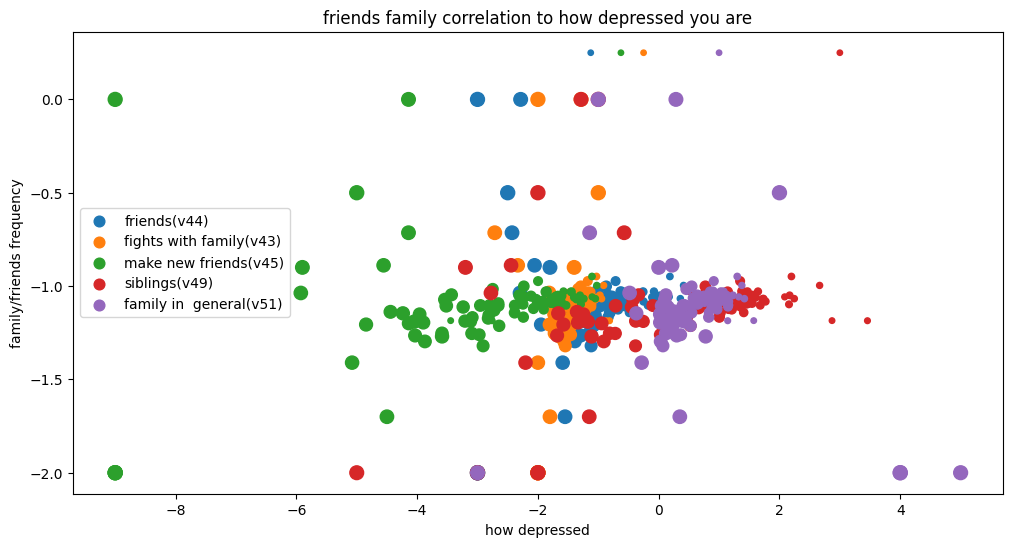

In [106]:
y = v55A["v55"]
x = allDep
x = scale.fit_transform(x)

x = sm.add_constant(x)
model = sm.OLS(y ,x)
result = model.fit()

print(result.summary())

#y_pred =result.predict(x)

#plt.plot(x,y_pred)
plt.scatter(allDep["v44"], y, allDep.index.map(getage))
plt.scatter(allDep["v43"], y, allDep.index.map(getage))
plt.scatter(allDep["v45"], y, allDep.index.map(getage))
plt.scatter(allDep["v49"], y, allDep.index.map(getage))
plt.scatter(allDep["v51"], y, allDep.index.map(getage))
plt.legend(["friends(v44)", "fights with family(v43)","make new friends(v45)", "siblings(v49)", "family in  general(v51)"])
plt.xlabel("how depressed")
plt.ylabel("family/friends frequency")
plt.title("friends family correlation to how depressed you are")
pd.DataFrame(pd.concat([allDep, y], axis=1).corr())


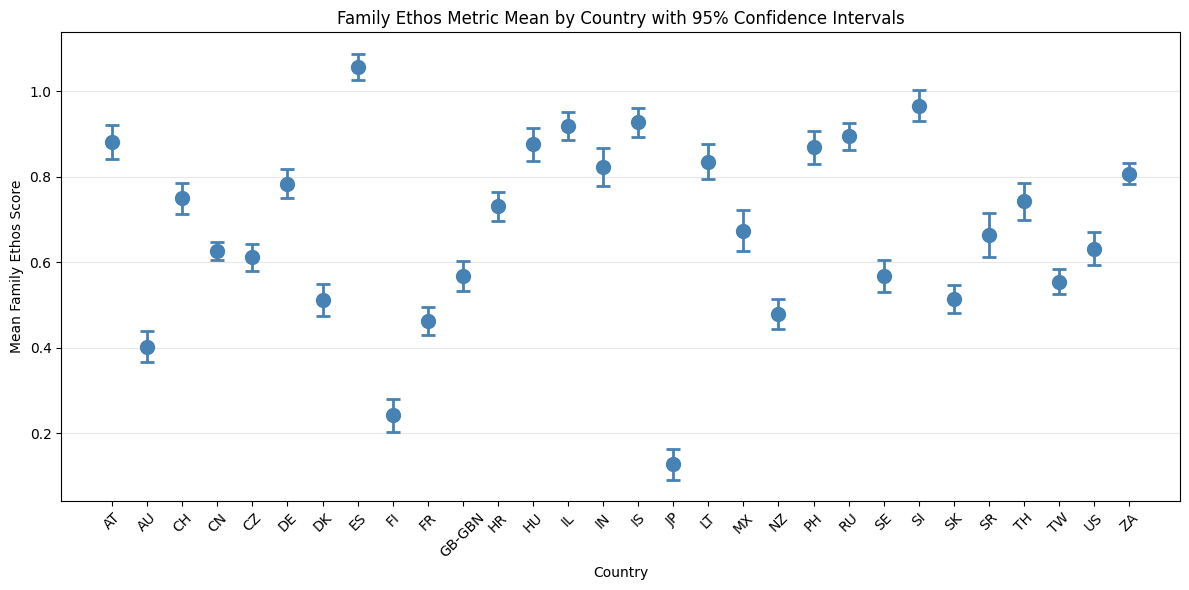

In [107]:

# Family ethos mean by country
family_df = pd.DataFrame({
    'country': df['c_alphan'],
    'v46': v46_mapped,
    'v47': v47_mapped,
    'v48': v48_mapped,
    'v41': v41_mapped,
    'v42': v42_mapped,
    'v49': v49_mapped,
    'v50': v50_mapped,
    'v51': v51_mapped,
    'v53': v53_mapped
})

# Calculate overall family mean for each row
family_df['overall_family_mean'] = family_df[['v46', 'v47', 'v48', 'v41', 'v42', 'v49', 'v50', 'v51', 'v53']].mean(axis=1)

# Group by country and calculate mean and 95% CI
countries = family_df['country'].unique()
means = []
cis_lower = []
cis_upper = []

for country in countries:
    country_data = family_df[family_df['country'] == country]['overall_family_mean']
    mean = country_data.mean()
    n = len(country_data)
    se = country_data.sem()  # Standard error
    ci = stats.t.interval(0.95, n-1, loc=mean, scale=se)
    
    means.append(mean)
    cis_lower.append(ci[0])
    cis_upper.append(ci[1])

# Create plot
fig, ax = plt.subplots(figsize=(12, 6))

# Plot error bars (confidence intervals) - vertical
x_pos = np.arange(len(countries))
errors = [np.array(means) - np.array(cis_lower), np.array(cis_upper) - np.array(means)]
ax.errorbar(x_pos, means, yerr=errors, fmt='none', ecolor='steelblue', capsize=5, capthick=2, linewidth=2)

# Plot means as dots
ax.scatter(x_pos, means, color='steelblue', s=100, zorder=3)


ax.set_xticks(x_pos)
ax.set_xticklabels(countries, rotation=45)
ax.set_xlabel('Country')
ax.set_ylabel('Mean Family Ethos Score')
ax.set_title('Family Ethos Metric Mean by Country with 95% Confidence Intervals')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Lower scores mean less communication with family (sibling, children, parents),
# less overall face to face communication with people and feeling more pressure to conform, 
# higher demands from family.

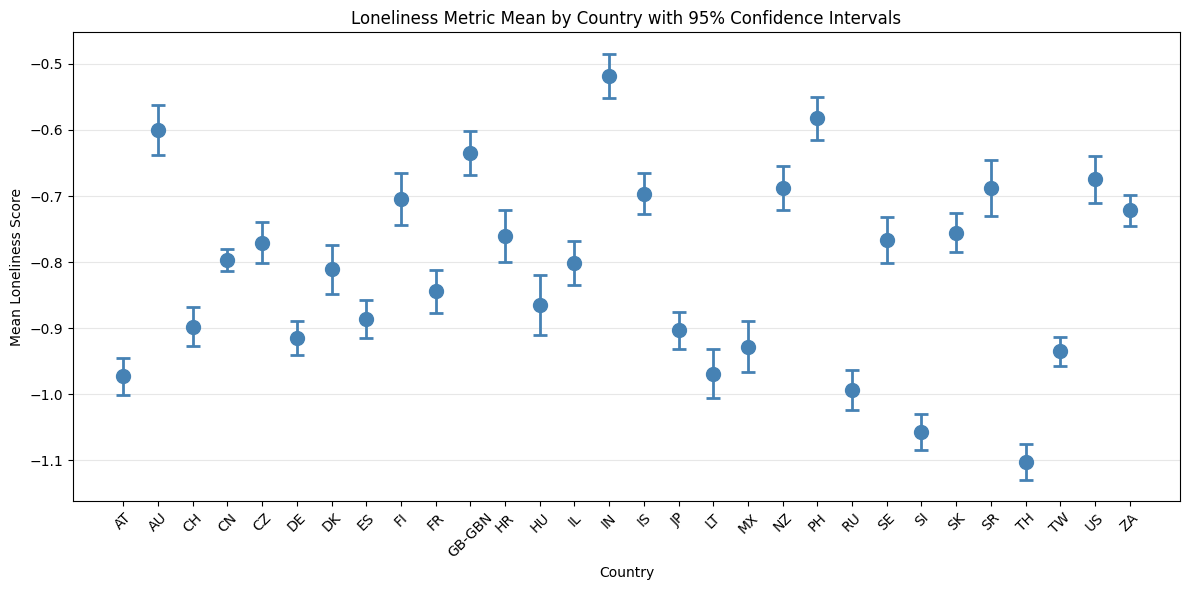

In [108]:


# Loneliness metric mean by country
loneliness_df = pd.DataFrame({
    'country': df['c_alphan'],
    'v31': v31_mapped,
    'v32': v32_mapped,
    'v33': v33_mapped,
    'v55': v55_mapped,
    'v56': v56_mapped,
    'v58': v58_mapped
})

# Calculate overall loneliness mean for each row
loneliness_df['overall_loneliness_mean'] = loneliness_df[['v31', 'v32', 'v33', 'v55', 'v56', 'v58']].mean(axis=1)

# Group by country and calculate mean and 95% CI
countries = sorted(loneliness_df['country'].unique())
means = []
cis_lower = []
cis_upper = []

for country in countries:
    country_data = loneliness_df[loneliness_df['country'] == country]['overall_loneliness_mean']
    mean = country_data.mean()
    n = len(country_data)
    se = country_data.sem()  # Standard error
    ci = stats.t.interval(0.95, n-1, loc=mean, scale=se)
    
    means.append(mean)
    cis_lower.append(ci[0])
    cis_upper.append(ci[1])

# Create plot
fig, ax = plt.subplots(figsize=(12, 6))

# Plot error bars (confidence intervals) - vertical
x_pos = np.arange(len(countries))
errors = [np.array(means) - np.array(cis_lower), np.array(cis_upper) - np.array(means)]
ax.errorbar(x_pos, means, yerr=errors, fmt='none', ecolor='steelblue', capsize=5, capthick=2, linewidth=2)

# Plot means as dots
ax.scatter(x_pos, means, color='steelblue', s=100, zorder=3)

ax.set_xticks(x_pos)
ax.set_xticklabels(countries, rotation=45)
ax.set_ylabel('Mean Loneliness Score')
ax.set_xlabel('Country')
ax.set_title('Loneliness Metric Mean by Country with 95% Confidence Intervals')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# A lower score indicates less loneliness, less feelings of isolation or depression,
# or difficulties that are piling up so high that you could not overcome them,
# and more overall satisfaction with life recently

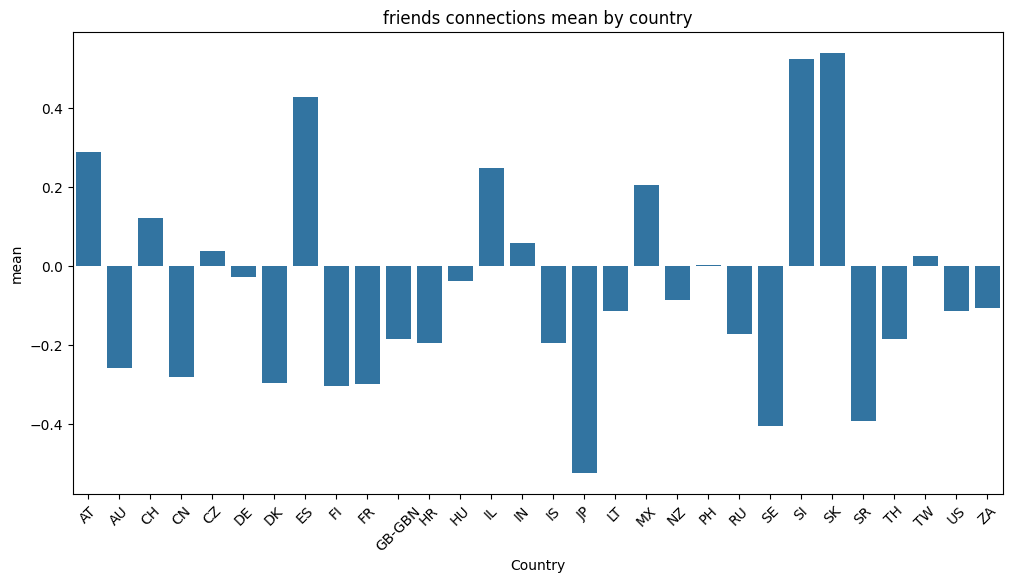

In [109]:
#friends connections mean by country

friends_df = pd.DataFrame({
    'country': df['c_alphan'],
    'v44': v44_mapped,
    'v45': v45_mapped,
    'v46': v46_mapped,
    'v47': v47_mapped,
    'v52': v52_mapped
})

#mean per column
friends_mean = friends_df.groupby('country').mean()
#overall mean for the metric
friends_mean['overall_friends_mean'] = friends_mean.mean(axis=1)

sns.barplot(x=friends_mean.index, y=friends_mean['overall_friends_mean'])
plt.title('friends connections mean by country')
plt.xlabel('Country')       
plt.ylabel('mean')
plt.xticks(rotation=45)
plt.show()  

#higher scores indicate more frequent communication with friends, more frequent face to face meeting and making new friends


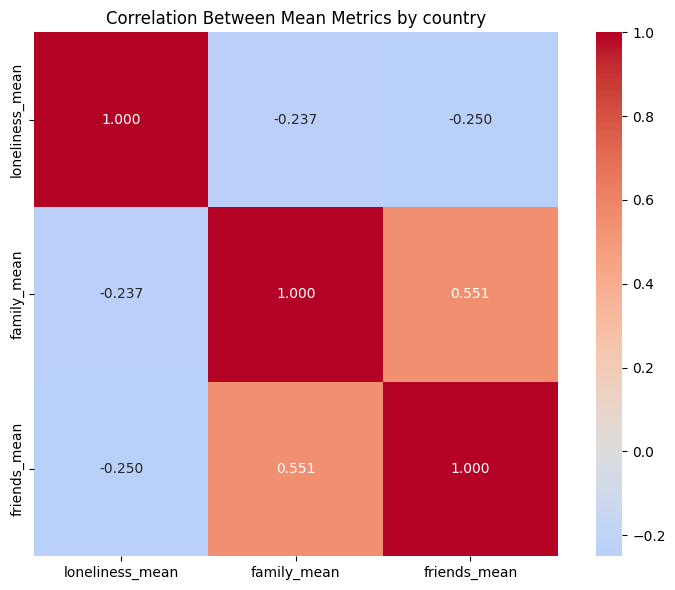

In [110]:
# Calculate mean scores for each metric category by country
loneliness_mean = loneliness_df.groupby('country')['overall_loneliness_mean'].mean()
family_mean = family_df.groupby('country')['overall_family_mean'].mean()

all_metrics = pd.DataFrame({
    'loneliness_mean': loneliness_mean,
    #'trust_mean': trust_mean['overall_trust_mean'],
    'family_mean': family_mean,
    'friends_mean': friends_mean['overall_friends_mean']
})

# Create correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(all_metrics.corr(), annot=True, fmt='.3f', cmap='coolwarm', center=0, square=True)
plt.title('Correlation Between Mean Metrics by country')
plt.tight_layout()
plt.show()

#more communication with family means more communication with friends. and some questions overlap
#the stronger one's friendships are the less one's loneliness is, and vice versa. though its nominal
#more communication with family means less loneliness, and vice versa. though its nominal
#stronger friendships mean less trust in people and corp ??
#stronger connection with family mean less trust in people and corp ??

In [111]:
df['age_numeric'] = pd.to_numeric(df['AGE'], errors='coerce')
df['age_decade'] = (df['age_numeric'] // 10 * 10)


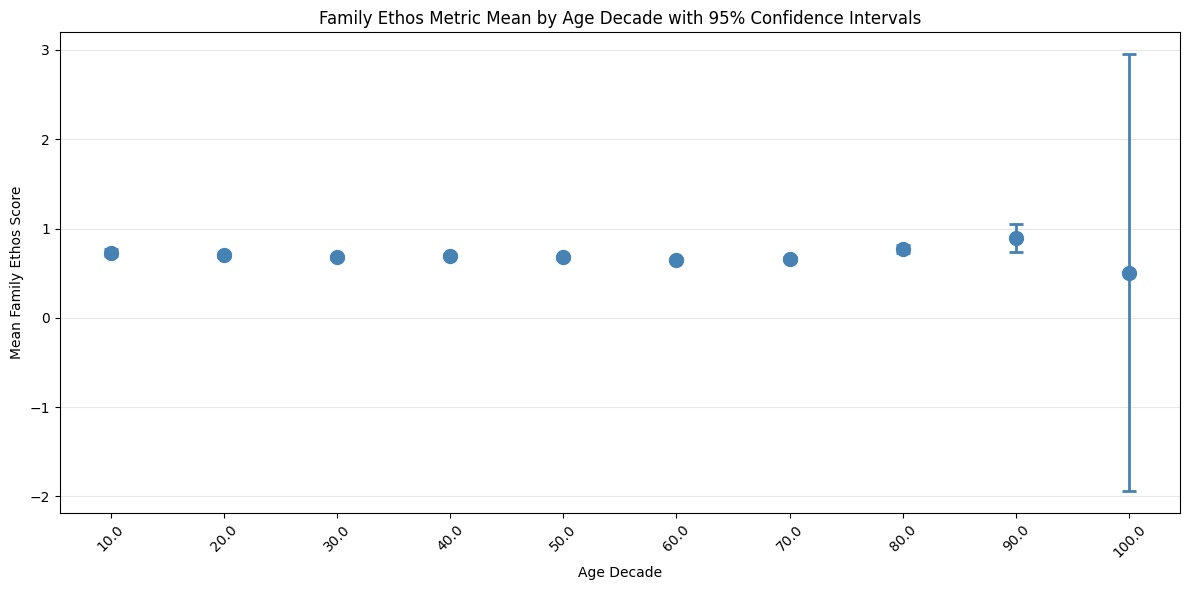

In [112]:

family_age_df = pd.DataFrame({
    'age_decade': df['age_decade'],
    'v46': v46_mapped, 'v47': v47_mapped, 'v48': v48_mapped,
    'v41': v41_mapped, 'v42': v42_mapped, 'v49': v49_mapped,
    'v50': v50_mapped, 'v51': v51_mapped, 'v53': v53_mapped
})

# Calculate overall trust age mean for each row
family_age_df['overall_family_ethos_age_mean'] = family_age_df[['v46', 'v47', 'v48', 'v41', 'v42', 'v49', 'v50', 'v51', 'v53']].mean(axis=1)

# Group by age_decade and calculate mean and 95% CI
# Sort numerically, handling NaN values
ages = sorted([age for age in family_age_df['age_decade'].unique() if pd.notna(age)])
means = []
cis_lower = []
cis_upper = []

for age in ages:
    age_data = family_age_df[family_age_df['age_decade'] == age]['overall_family_ethos_age_mean']
    mean = age_data.mean()
    n = len(age_data)
    se = age_data.sem()  # Standard error
    ci = stats.t.interval(0.95, n-1, loc=mean, scale=se)
    
    means.append(mean)
    cis_lower.append(ci[0])
    cis_upper.append(ci[1])


# Create plot
fig, ax = plt.subplots(figsize=(12, 6))

# Plot error bars (confidence intervals) - vertical
x_pos = np.arange(len(ages))
errors = [np.array(means) - np.array(cis_lower), np.array(cis_upper) - np.array(means)]
ax.errorbar(x_pos, means, yerr=errors, fmt='none', ecolor='steelblue', capsize=5, capthick=2, linewidth=2)

# Plot means as dots
ax.scatter(x_pos, means, color='steelblue', s=100, zorder=3)

ax.set_xticks(x_pos)
ax.set_xticklabels(ages, rotation=45)
ax.set_ylabel('Mean Family Ethos Score')
ax.set_xlabel('Age Decade')
ax.set_title('Family Ethos Metric Mean by Age Decade with 95% Confidence Intervals')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


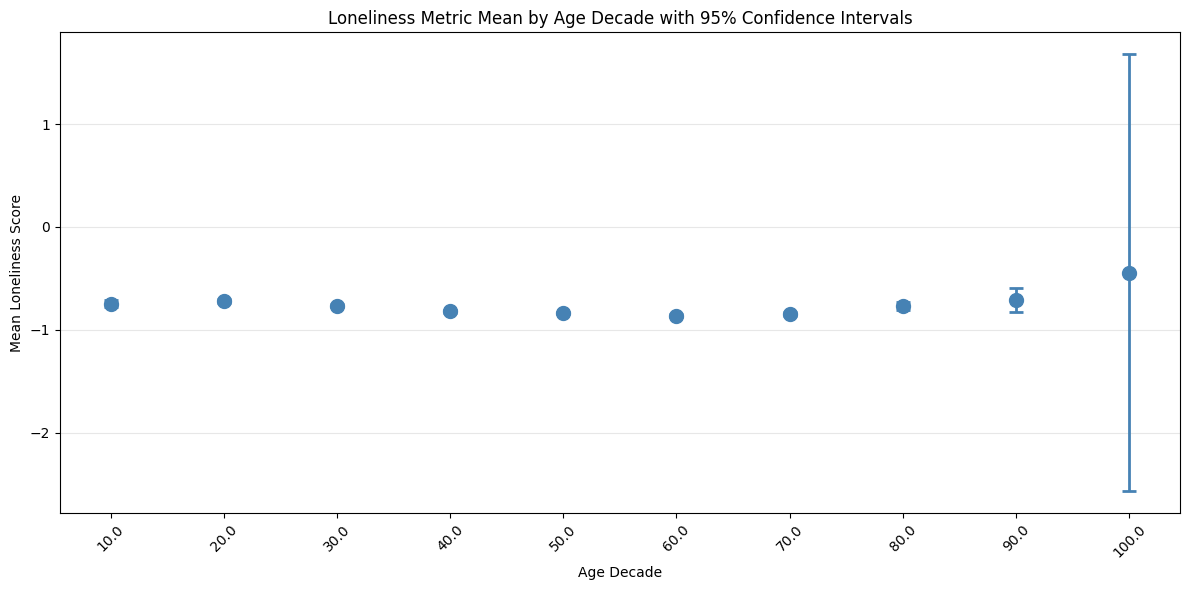

In [113]:

loneliness_age_df = pd.DataFrame({
    'age_decade': df['age_decade'],
     'v31': v31_mapped,
    'v32': v32_mapped,
    'v33': v33_mapped,
    'v55': v55_mapped,
    'v56': v56_mapped,
    'v58': v58_mapped
    
})

# Calculate overall trust age mean for each row
loneliness_age_df['overall_loneliness_age_mean'] = loneliness_age_df[['v31', 'v32', 'v33', 'v55', 'v56', 'v58']].mean(axis=1)

# Group by age_decade and calculate mean and 95% CI
# Sort numerically, handling NaN values
ages = sorted([age for age in loneliness_age_df['age_decade'].unique() if pd.notna(age)])
means = []
cis_lower = []
cis_upper = []

for age in ages:
    age_data = loneliness_age_df[loneliness_age_df['age_decade'] == age]['overall_loneliness_age_mean']
    mean = age_data.mean()
    n = len(age_data)
    se = age_data.sem()  # Standard error
    ci = stats.t.interval(0.95, n-1, loc=mean, scale=se)
    
    means.append(mean)
    cis_lower.append(ci[0])
    cis_upper.append(ci[1])


# Create plot
fig, ax = plt.subplots(figsize=(12, 6))

# Plot error bars (confidence intervals) - vertical
x_pos = np.arange(len(ages))
errors = [np.array(means) - np.array(cis_lower), np.array(cis_upper) - np.array(means)]
ax.errorbar(x_pos, means, yerr=errors, fmt='none', ecolor='steelblue', capsize=5, capthick=2, linewidth=2)

# Plot means as dots
ax.scatter(x_pos, means, color='steelblue', s=100, zorder=3)

ax.set_xticks(x_pos)
ax.set_xticklabels(ages, rotation=45)
ax.set_ylabel('Mean Loneliness Score')
ax.set_xlabel('Age Decade')
ax.set_title('Loneliness Metric Mean by Age Decade with 95% Confidence Intervals')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

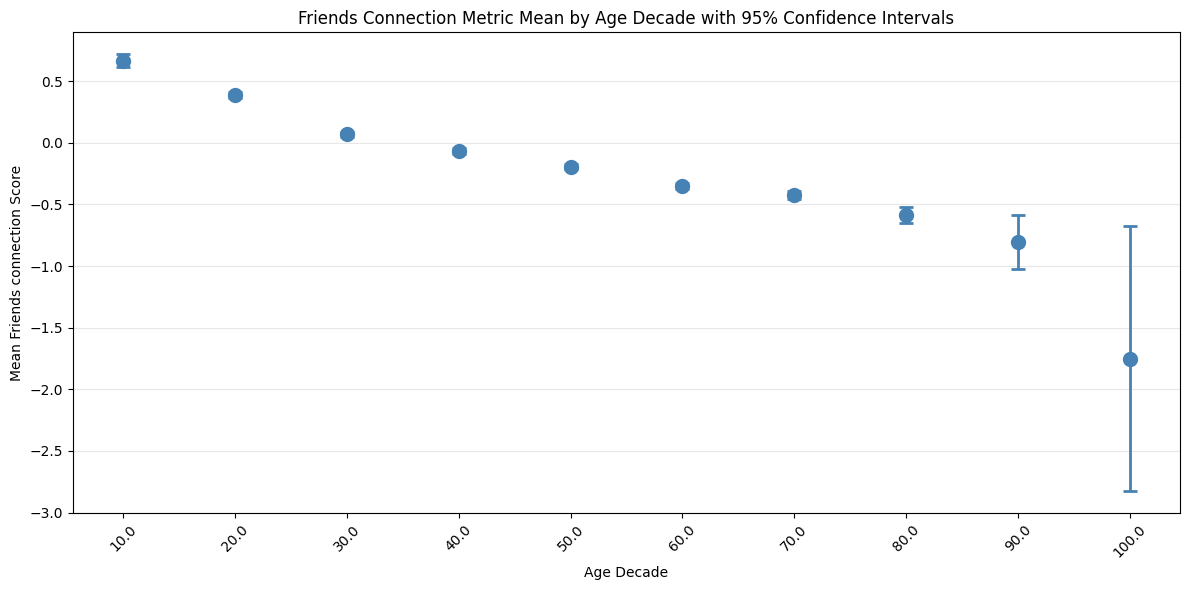

In [114]:
friends_age_df = pd.DataFrame({
    'age_decade': df['age_decade'],
    'v44': v44_mapped,
    'v45': v45_mapped,
    'v46': v46_mapped,
    'v47': v47_mapped,
    'v52': v52_mapped
    
})


# Calculate overall trust age mean for each row
friends_age_df['overall_friends_age_mean'] = friends_age_df[['v44', 'v45', 'v46', 'v47', 'v52']].mean(axis=1)

# Group by age_decade and calculate mean and 95% CI
# Sort numerically, handling NaN values
ages = sorted([age for age in friends_age_df['age_decade'].unique() if pd.notna(age)])
means = []
cis_lower = []
cis_upper = []

for age in ages:
    age_data = friends_age_df[friends_age_df['age_decade'] == age]['overall_friends_age_mean']
    mean = age_data.mean()
    n = len(age_data)
    se = age_data.sem()  # Standard error
    ci = stats.t.interval(0.95, n-1, loc=mean, scale=se)
    
    means.append(mean)
    cis_lower.append(ci[0])
    cis_upper.append(ci[1])


# Create plot
fig, ax = plt.subplots(figsize=(12, 6))

# Plot error bars (confidence intervals) - vertical
x_pos = np.arange(len(ages))
errors = [np.array(means) - np.array(cis_lower), np.array(cis_upper) - np.array(means)]
ax.errorbar(x_pos, means, yerr=errors, fmt='none', ecolor='steelblue', capsize=5, capthick=2, linewidth=2)

# Plot means as dots
ax.scatter(x_pos, means, color='steelblue', s=100, zorder=3)

ax.set_xticks(x_pos)
ax.set_xticklabels(ages, rotation=45)
ax.set_ylabel('Mean Friends connection Score')
ax.set_xlabel('Age Decade')
ax.set_title('Friends Connection Metric Mean by Age Decade with 95% Confidence Intervals')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


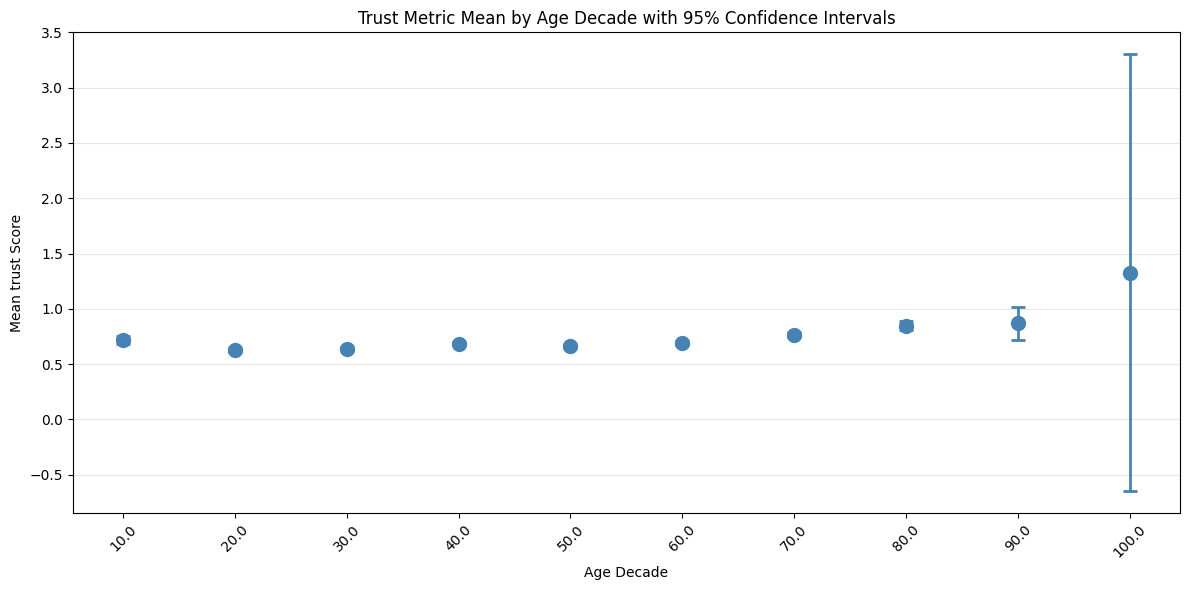

In [124]:
trust_age_df = pd.DataFrame({
    'age_decade': df['age_decade'],
    'v34': v34_mapped,
    'v35': v35_mapped,
    'v36': v36_mapped,
    'v37': v37_mapped
})


# Calculate overall trust age mean for each row
trust_age_df['overall_trust_age_mean'] = trust_age_df[['v34', 'v35', 'v36', 'v37']].mean(axis=1)

# Group by age_decade and calculate mean and 95% CI
# Sort numerically, handling NaN values
ages = sorted([age for age in trust_age_df['age_decade'].unique() if pd.notna(age)])
means = []
cis_lower = []
cis_upper = []

for age in ages:
    age_data = trust_age_df[trust_age_df['age_decade'] == age]['overall_trust_age_mean']
    mean = age_data.mean()
    n = len(age_data)
    se = age_data.sem()  # Standard error
    ci = stats.t.interval(0.95, n-1, loc=mean, scale=se)
    
    means.append(mean)
    cis_lower.append(ci[0])
    cis_upper.append(ci[1])


# Create plot
fig, ax = plt.subplots(figsize=(12, 6))

# Plot error bars (confidence intervals) - vertical
x_pos = np.arange(len(ages))
errors = [np.array(means) - np.array(cis_lower), np.array(cis_upper) - np.array(means)]
ax.errorbar(x_pos, means, yerr=errors, fmt='none', ecolor='steelblue', capsize=5, capthick=2, linewidth=2)

# Plot means as dots
ax.scatter(x_pos, means, color='steelblue', s=100, zorder=3)

ax.set_xticks(x_pos)
ax.set_xticklabels(ages, rotation=45)
ax.set_ylabel('Mean trust Score')
ax.set_xlabel('Age Decade')
ax.set_title('Trust Metric Mean by Age Decade with 95% Confidence Intervals')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()



In [125]:
# Dictionary to store metrics data - maps to actual dataframes
metrics_age = {
    'Family Ethos': (family_age_df, 'overall_family_ethos_age_mean'),
    'Loneliness': (loneliness_age_df, 'overall_loneliness_age_mean'),
    'Trust': (trust_age_df, 'overall_trust_age_mean'),
    'Friends': (friends_age_df, 'overall_friends_age_mean')
}

# Get unique age groups
all_ages = sorted([g for g in family_age_df['age_decade'].unique() if pd.notna(g)])

# Calculate means for each metric at each age
metric_means_by_age = {}
for metric_name, (df_obj, mean_col) in metrics_age.items():
    metric_means_by_age[metric_name] = [df_obj[df_obj['age_decade'] == age][mean_col].mean() for age in all_ages]

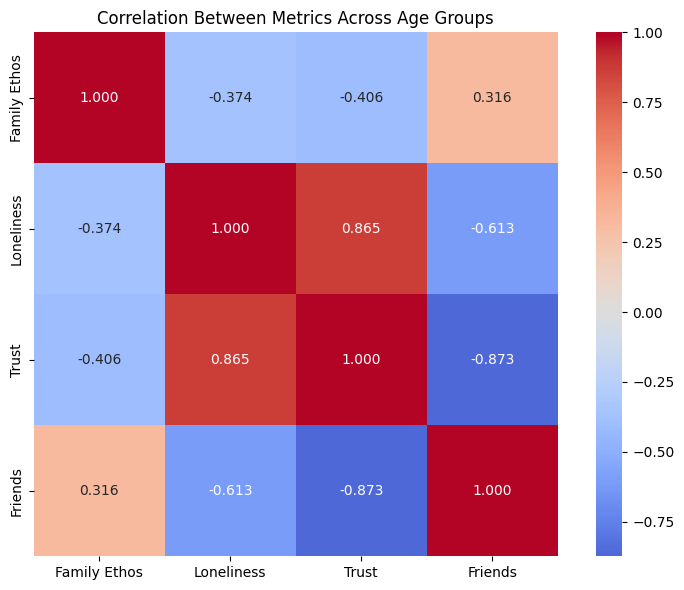

In [126]:


# Create DataFrame - metrics as columns, ages as rows
all_metrics = pd.DataFrame(metric_means_by_age, index=all_ages)

# Create correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(all_metrics.corr(), annot=True, fmt='.3f', cmap='coolwarm', center=0, square=True)
plt.title('Correlation Between Metrics Across Age Groups')
plt.tight_layout()
plt.show()

# all_metrics is now available for reuse
#more loneliness means more trust ??
#stronger friendships mean less trust in people and corp ??
#stronger connection with family mean less trust in people and corp ??
# I think these changes more so relate to the age then to each other
#BUT we do get a -0.6 correlation between loneliness and friends by age so more friendships mean less loneliness

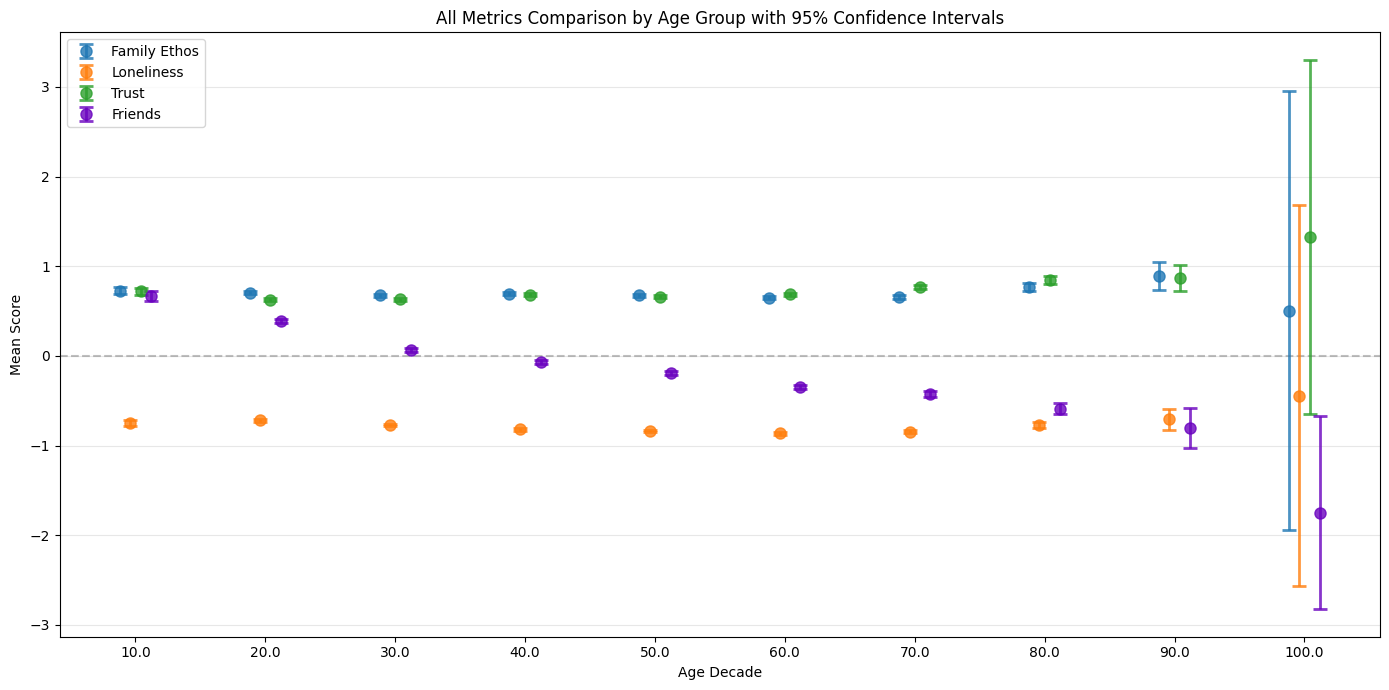

In [127]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

colors = {'Family Ethos': '#1f77b4', 'Loneliness': '#ff7f0e', 'Trust': '#2ca02c', 'Friends': '#6a02bf'}

# Create plot
fig, ax = plt.subplots(figsize=(14, 7))

# Offset for grouping dots by metric within each age
offset = 0.08
metric_names = list(all_metrics.columns)
n_metrics = len(metric_names)

# For each metric
for metric_idx, metric_name in enumerate(metric_names):
    df_obj, mean_col = metrics_age[metric_name]
    means = all_metrics[metric_name].values
    
    # Calculate 95% CI for each age group from raw data
    cis = []
    for age in all_ages:
        age_data = df_obj[df_obj['age_decade'] == age][mean_col].dropna()
        if len(age_data) > 1:
            sem = stats.sem(age_data)
            ci = sem * stats.t.ppf(0.975, len(age_data) - 1)
        else:
            ci = 0
        cis.append(ci)
    
    cis = np.array(cis)
    
    # Plot this metric's data
    x_pos = np.arange(len(all_ages))
    x_offset = x_pos + (metric_idx - n_metrics/2 + 0.5) * offset
    
    # Scatter plot with error bars (vertical lines for CI)
    ax.errorbar(x_offset, means, yerr=cis, fmt='o', 
                color=colors[metric_name], ecolor=colors[metric_name],
                markersize=8, capsize=5, capthick=2, 
                elinewidth=2, zorder=3, label=metric_name, alpha=0.8)

ax.set_xticks(np.arange(len(all_ages)))
ax.set_xticklabels(all_ages)
ax.set_xlabel('Age Decade')
ax.set_ylabel('Mean Score')
ax.set_title('All Metrics Comparison by Age Group with 95% Confidence Intervals')
ax.legend(loc='best', fontsize=10)
ax.grid(axis='y', alpha=0.3)
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

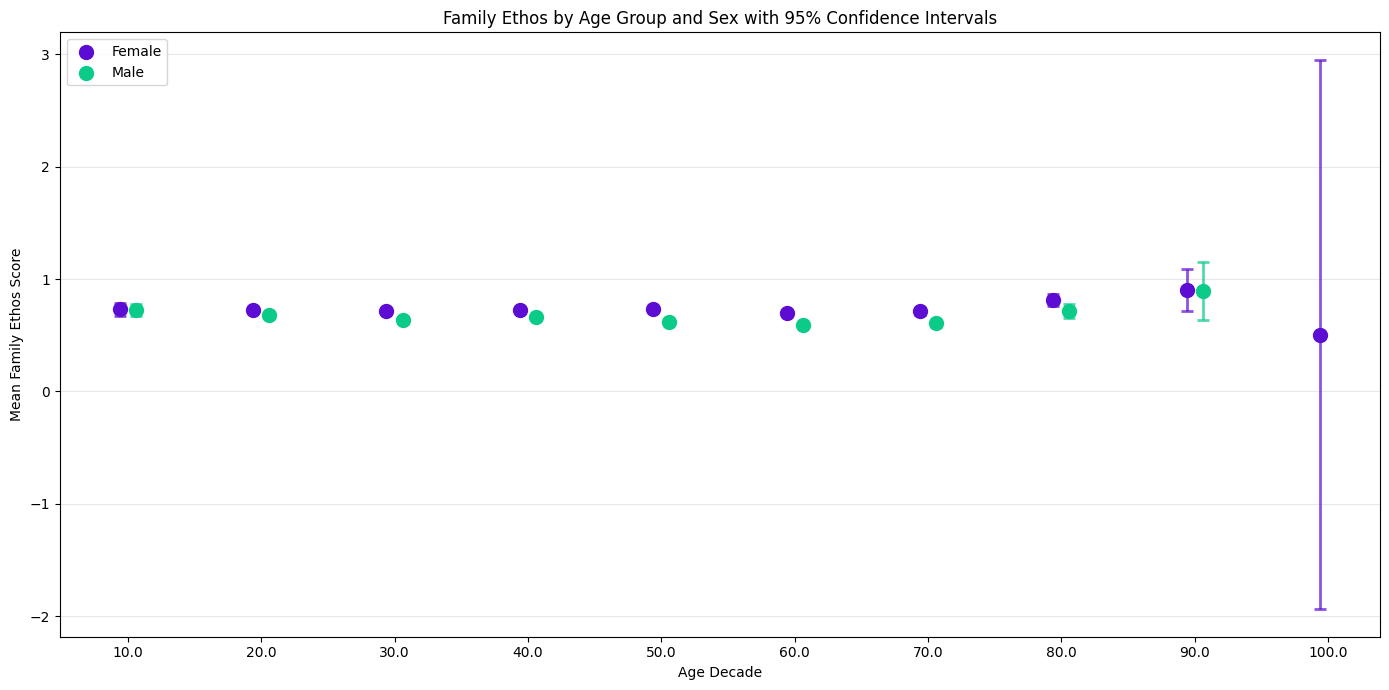

In [ ]:
# Choose which metric to plot
metric_df = family_age_df.copy()  # Change this to whichever metric you want
metric_name = 'Family Ethos'
mean_col = 'overall_family_ethos_age_mean'

# Add SEX column from original df
metric_df['SEX'] = df['SEX']

# Get unique age groups and sex values
all_ages = sorted([g for g in metric_df['age_decade'].unique() if pd.notna(g)])
sex_values = sorted([s for s in metric_df['SEX'].unique() if pd.notna(s)])

# Create plot
fig, ax = plt.subplots(figsize=(14, 7))

# Offset for grouping dots by sex within each age
offset = 0.12
colors_sex = {'Male': "#0acb88", 'Female': "#5c0cd3"}

# For each sex
for sex_idx, sex in enumerate(sex_values):
    means = []
    cis_lower = []
    cis_upper = []
    
    # Calculate for each age group
    for age in all_ages:
        age_sex_data = metric_df[(metric_df['age_decade'] == age) & (metric_df['SEX'] == sex)][mean_col]
        
        if len(age_sex_data) > 1:  # Need at least 2 points for CI
            mean = age_sex_data.mean()
            n = len(age_sex_data)
            se = age_sex_data.sem()
            ci = stats.t.interval(0.95, n-1, loc=mean, scale=se)
            
            means.append(mean)
            cis_lower.append(ci[0])
            cis_upper.append(ci[1])
        else:
            means.append(np.nan)
            cis_lower.append(np.nan)
            cis_upper.append(np.nan)
    
    # Plot this sex's data
    x_pos = np.arange(len(all_ages))
    x_offset = x_pos + (sex_idx - len(sex_values)/2 + 0.5) * offset
    
    errors = [np.array(means) - np.array(cis_lower), 
              np.array(cis_upper) - np.array(means)]
    
    sex_label = f'Sex {sex}' if isinstance(sex, int) else sex
    ax.errorbar(x_offset, means, yerr=errors, fmt='none', 
                ecolor=colors_sex.get(sex, 'steelblue'), capsize=4, capthick=2, linewidth=2, alpha=0.7)
    ax.scatter(x_offset, means, color=colors_sex.get(sex, 'steelblue'), s=100, zorder=3, label=sex_label)

ax.set_xticks(np.arange(len(all_ages)))
ax.set_xticklabels(all_ages)
ax.set_xlabel('Age Decade')
ax.set_ylabel(f'Mean {metric_name} Score')
ax.set_title(f'{metric_name} by Age Group and Sex with 95% Confidence Intervals')
ax.legend(loc='best', fontsize=10)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

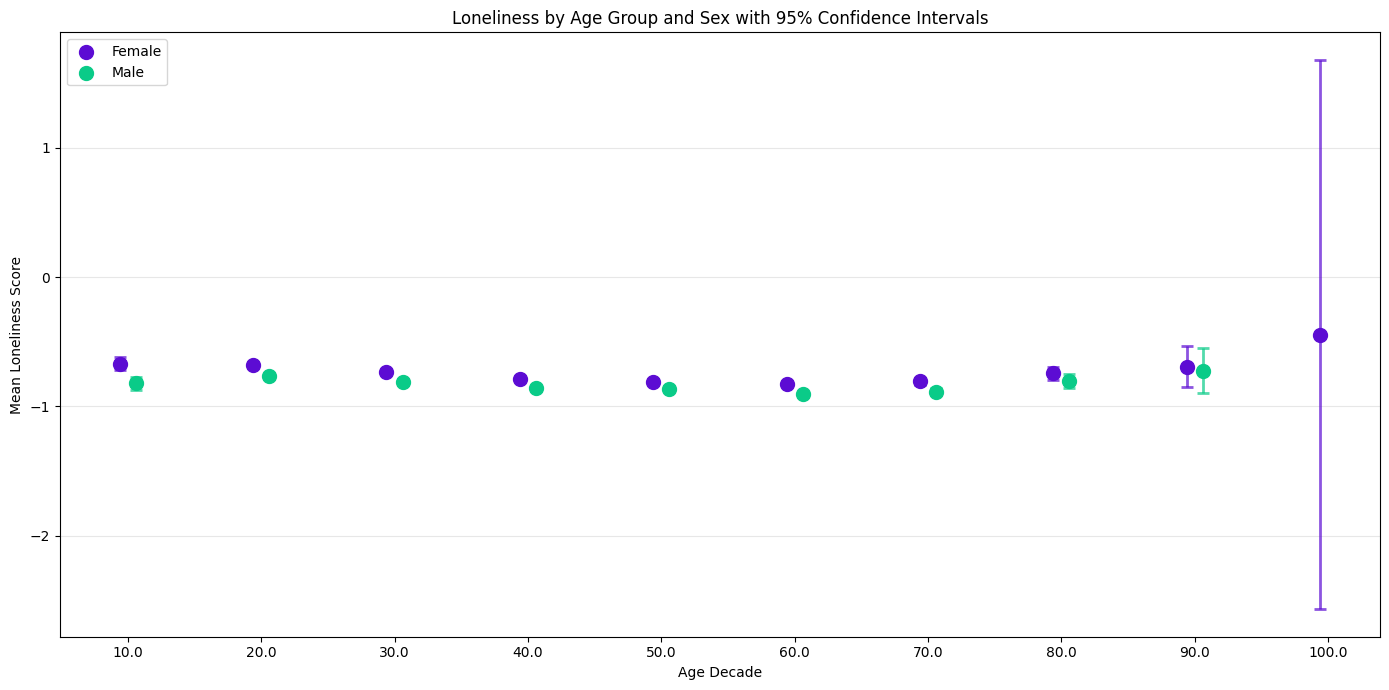

In [ ]:
# Choose which metric to plot
metric_df = loneliness_age_df.copy()  # Change this to whichever metric you want
metric_name = 'Loneliness'
mean_col = 'overall_loneliness_age_mean'

# Add SEX column from original df
metric_df['SEX'] = df['SEX']

# Get unique age groups and sex values
all_ages = sorted([g for g in metric_df['age_decade'].unique() if pd.notna(g)])
sex_values = sorted([s for s in metric_df['SEX'].unique() if pd.notna(s)])

# Create plot
fig, ax = plt.subplots(figsize=(14, 7))

# Offset for grouping dots by sex within each age
offset = 0.12
colors_sex = {'Male': "#0acb88", 'Female': "#5c0cd3"}

# For each sex
for sex_idx, sex in enumerate(sex_values):
    means = []
    cis_lower = []
    cis_upper = []
    
    # Calculate for each age group
    for age in all_ages:
        age_sex_data = metric_df[(metric_df['age_decade'] == age) & (metric_df['SEX'] == sex)][mean_col]
        
        if len(age_sex_data) > 1:  # Need at least 2 points for CI
            mean = age_sex_data.mean()
            n = len(age_sex_data)
            se = age_sex_data.sem()
            ci = stats.t.interval(0.95, n-1, loc=mean, scale=se)
            
            means.append(mean)
            cis_lower.append(ci[0])
            cis_upper.append(ci[1])
        else:
            means.append(np.nan)
            cis_lower.append(np.nan)
            cis_upper.append(np.nan)
    
    # Plot this sex's data
    x_pos = np.arange(len(all_ages))
    x_offset = x_pos + (sex_idx - len(sex_values)/2 + 0.5) * offset
    
    errors = [np.array(means) - np.array(cis_lower), 
              np.array(cis_upper) - np.array(means)]
    
    sex_label = f'Sex {sex}' if isinstance(sex, int) else sex
    ax.errorbar(x_offset, means, yerr=errors, fmt='none', 
                ecolor=colors_sex.get(sex, 'steelblue'), capsize=4, capthick=2, linewidth=2, alpha=0.7)
    ax.scatter(x_offset, means, color=colors_sex.get(sex, 'steelblue'), s=100, zorder=3, label=sex_label)

ax.set_xticks(np.arange(len(all_ages)))
ax.set_xticklabels(all_ages)
ax.set_xlabel('Age Decade')
ax.set_ylabel(f'Mean {metric_name} Score')
ax.set_title(f'{metric_name} by Age Group and Sex with 95% Confidence Intervals')
ax.legend(loc='best', fontsize=10)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

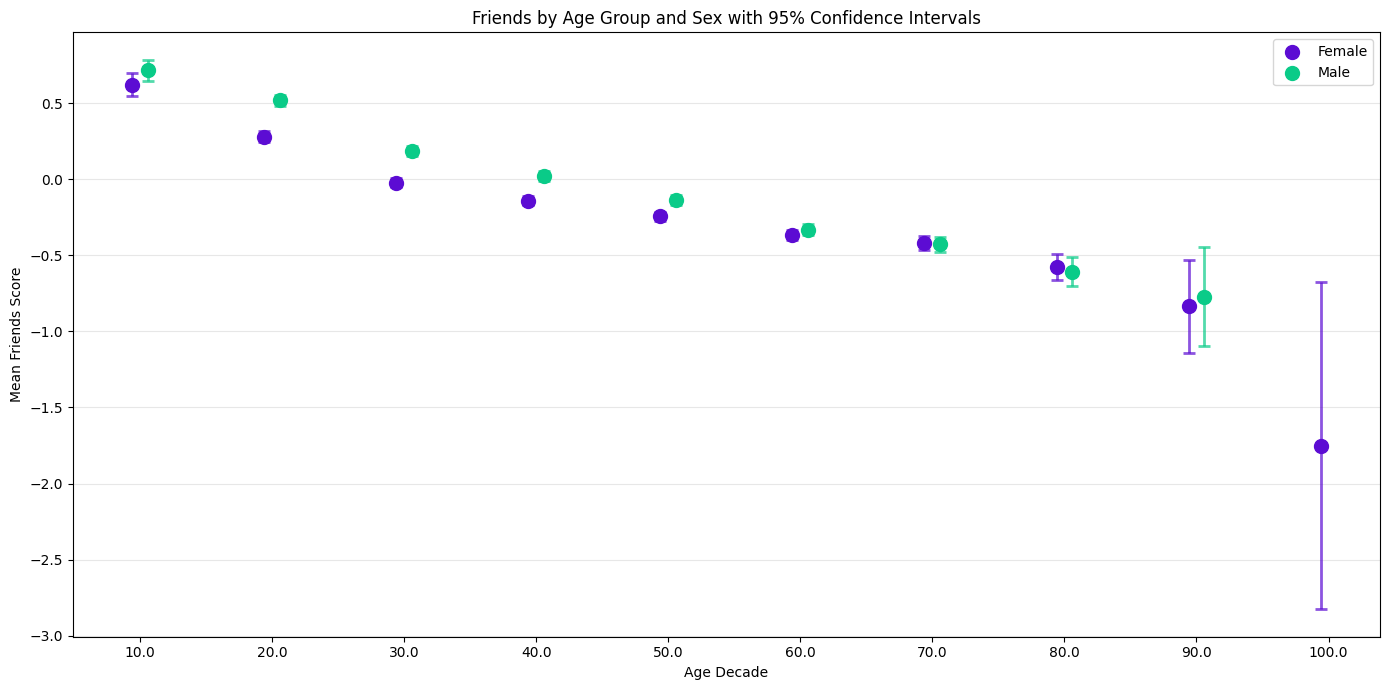

In [ ]:
# Choose which metric to plot
metric_df = friends_age_df.copy()  # Change this to whichever metric you want
metric_name = 'Friends'
mean_col = 'overall_friends_age_mean'

# Add SEX column from original df
metric_df['SEX'] = df['SEX']

# Get unique age groups and sex values
all_ages = sorted([g for g in metric_df['age_decade'].unique() if pd.notna(g)])
sex_values = sorted([s for s in metric_df['SEX'].unique() if pd.notna(s)])

# Create plot
fig, ax = plt.subplots(figsize=(14, 7))

# Offset for grouping dots by sex within each age
offset = 0.12
colors_sex = {'Male': "#0acb88", 'Female': "#5c0cd3"}

# For each sex
for sex_idx, sex in enumerate(sex_values):
    means = []
    cis_lower = []
    cis_upper = []
    
    # Calculate for each age group
    for age in all_ages:
        age_sex_data = metric_df[(metric_df['age_decade'] == age) & (metric_df['SEX'] == sex)][mean_col]
        
        if len(age_sex_data) > 1:  # Need at least 2 points for CI
            mean = age_sex_data.mean()
            n = len(age_sex_data)
            se = age_sex_data.sem()
            ci = stats.t.interval(0.95, n-1, loc=mean, scale=se)
            
            means.append(mean)
            cis_lower.append(ci[0])
            cis_upper.append(ci[1])
        else:
            means.append(np.nan)
            cis_lower.append(np.nan)
            cis_upper.append(np.nan)
    
    # Plot this sex's data
    x_pos = np.arange(len(all_ages))
    x_offset = x_pos + (sex_idx - len(sex_values)/2 + 0.5) * offset
    
    errors = [np.array(means) - np.array(cis_lower), 
              np.array(cis_upper) - np.array(means)]
    
    sex_label = f'Sex {sex}' if isinstance(sex, int) else sex
    ax.errorbar(x_offset, means, yerr=errors, fmt='none', 
                ecolor=colors_sex.get(sex, 'steelblue'), capsize=4, capthick=2, linewidth=2, alpha=0.7)
    ax.scatter(x_offset, means, color=colors_sex.get(sex, 'steelblue'), s=100, zorder=3, label=sex_label)

ax.set_xticks(np.arange(len(all_ages)))
ax.set_xticklabels(all_ages)
ax.set_xlabel('Age Decade')
ax.set_ylabel(f'Mean {metric_name} Score')
ax.set_title(f'{metric_name} by Age Group and Sex with 95% Confidence Intervals')
ax.legend(loc='best', fontsize=10)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()